In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
dataset_path = "/content/drive/MyDrive/images.zip"

In [ ]:
!pip install seaborn

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [ ]:
import zipfile

with zipfile.ZipFile("/content/drive/MyDrive/images.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [ ]:
import os

base_path = "/content/images"
train_path = os.path.join(base_path, "training")
test_path = os.path.join(base_path, "testing")

classes = ["flip", "notflip"]

In [ ]:
from collections import Counter

def count_images(path):
    counter = {}
    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        counter[cls] = len(os.listdir(cls_path))
    return counter

train_counts = count_images(train_path)
test_counts = count_images(test_path)

print("Train:", train_counts)
print("Test:", test_counts)

Train: {'notflip': 1230, 'flip': 1162}
Test: {'notflip': 307, 'flip': 290}


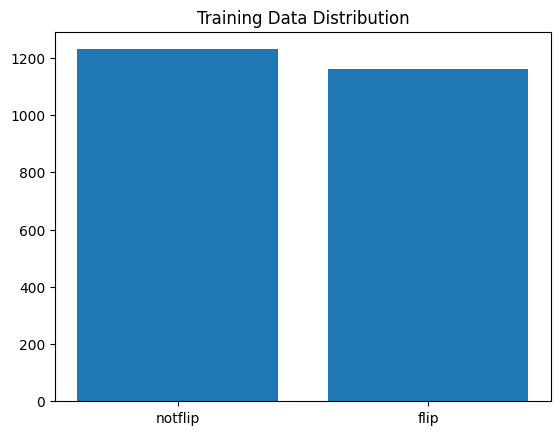

In [ ]:
import matplotlib.pyplot as plt

plt.bar(train_counts.keys(), train_counts.values())
plt.title("Training Data Distribution")
plt.show()

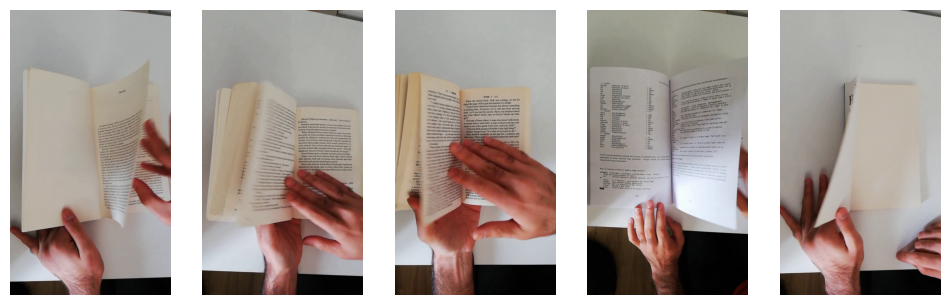

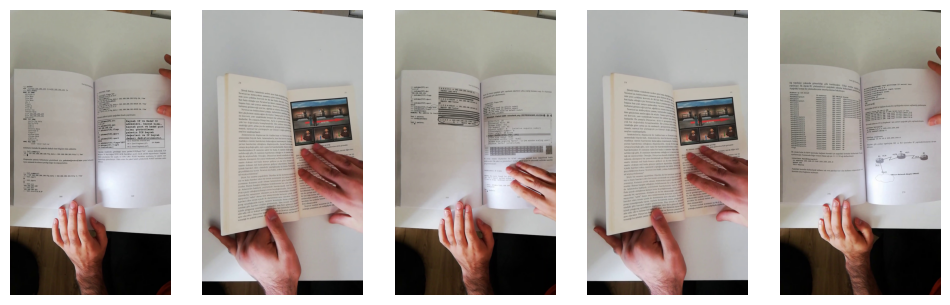

In [ ]:
import random
from PIL import Image

def show_samples(path, cls):
    cls_path = os.path.join(path, cls)
    imgs = random.sample(os.listdir(cls_path), 5)

    plt.figure(figsize=(12,4))
    for i, img_name in enumerate(imgs):
        img = Image.open(os.path.join(cls_path, img_name))
        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.show()

show_samples(train_path, "flip")
show_samples(train_path, "notflip")

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
base_path = "/content/images"
train_path = os.path.join(base_path, "training")
test_path = os.path.join(base_path, "testing")
classes = ["notflip", "flip"]  # 0: notflip, 1: flip

BATCH_SIZE = 32
IMG_SIZE = 128
EPOCHS = 20
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


In [ ]:
class FlipDataset(Dataset):
    def __init__(self, root_path, transform=None):
        self.samples = []
        self.transform = transform
        for label, cls in enumerate(classes):
            cls_path = os.path.join(root_path, cls)
            for fname in os.listdir(cls_path):
                fpath = os.path.join(cls_path, fname)
                self.samples.append((fpath, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
train_dataset = FlipDataset(train_path, transform=train_transform)
test_dataset = FlipDataset(test_path, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

Train: 2392, Test: 597


Epoch 1/20: 100%|██████████| 75/75 [03:36<00:00,  2.88s/it]


  Train Loss: 1.0891 Acc: 0.5560 | Test Loss: 0.5601 Acc: 0.7588


Epoch 2/20: 100%|██████████| 75/75 [03:10<00:00,  2.54s/it]


  Train Loss: 0.5407 Acc: 0.7375 | Test Loss: 0.3934 Acc: 0.8224


Epoch 3/20: 100%|██████████| 75/75 [03:09<00:00,  2.53s/it]


...

  Train Loss: 0.0701 Acc: 0.9724 | Test Loss: 0.0438 Acc: 0.9883


Epoch 19/20: 100%|██████████| 75/75 [03:16<00:00,  2.62s/it]


  Train Loss: 0.0704 Acc: 0.9749 | Test Loss: 0.0199 Acc: 0.9916


Epoch 20/20: 100%|██████████| 75/75 [03:16<00:00,  2.61s/it]


  Train Loss: 0.0905 Acc: 0.9670 | Test Loss: 0.0704 Acc: 0.9682


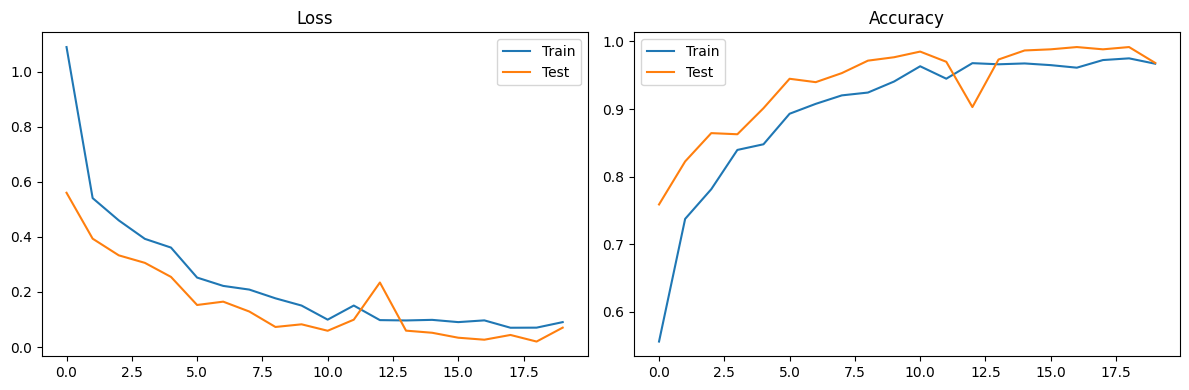

Model saved to flip_cnn.pth


In [ ]:
class FlipCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 128x128x3 -> 64x64x32
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2: 64x64x32 -> 32x32x64
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3: 32x32x64 -> 16x16x128
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4: 16x16x128 -> 8x8x256
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)  #BCEWithLogitsLoss
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)

model = FlipCNN().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

# ===========
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(EPOCHS):
    # Train
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, labels = imgs.to(DEVICE), labels.float().to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Eval
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.float().to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).long()
            correct += (preds == labels.long()).sum().item()
            total += labels.size(0)

    test_loss = running_loss / total
    test_acc = correct / total
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    scheduler.step(test_loss)

    print(f"  Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} Acc: {test_acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label="Train")
ax1.plot(test_losses, label="Test")
ax1.set_title("Loss"); ax1.legend()
ax2.plot(train_accs, label="Train")
ax2.plot(test_accs, label="Test")
ax2.set_title("Accuracy"); ax2.legend()
plt.tight_layout(); plt.show()

torch.save(model.state_dict(), "flip_cnn.pth")
print("Model saved to flip_cnn.pth")

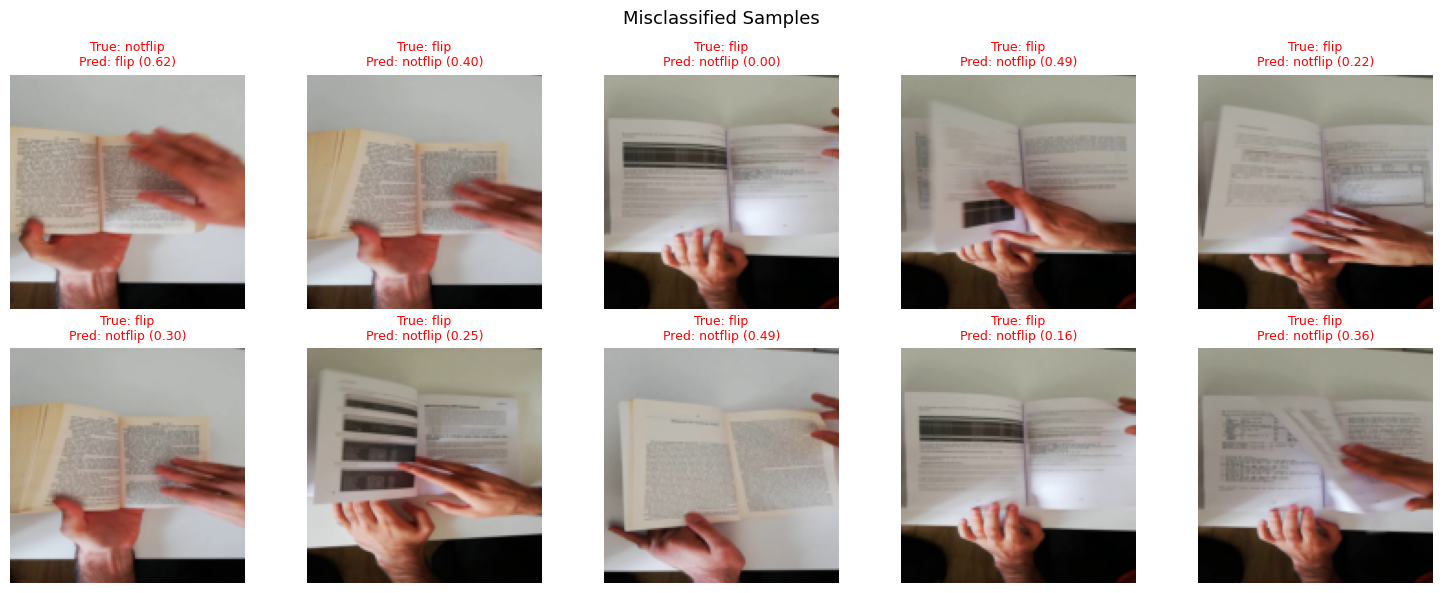

In [ ]:
def show_misclassified(loader, n=10):
    model.eval()
    wrong_imgs, wrong_info = [], []

    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    with torch.no_grad():
        for imgs, labels in loader:
            outputs = model(imgs.to(DEVICE))
            probs = torch.sigmoid(outputs).cpu()
            preds = (probs > 0.5).long()

            for i in range(imgs.size(0)):
                if preds[i] != labels[i]:
                    img = inv_normalize(imgs[i]).clamp(0, 1).permute(1, 2, 0).numpy()
                    wrong_imgs.append(img)
                    wrong_info.append({
                        'true': classes[labels[i]],
                        'pred': classes[preds[i]],
                        'prob': probs[i].item()
                    })
            if len(wrong_imgs) >= n:
                break

    if not wrong_imgs:
        print("No misclassified samples!")
        return

    cols = min(5, len(wrong_imgs))
    rows = (len(wrong_imgs[:n]) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    if rows == 1:
        axes = [axes] if cols == 1 else axes
    axes = np.array(axes).flatten()

    for i, (img, info) in enumerate(zip(wrong_imgs[:n], wrong_info[:n])):
        axes[i].imshow(img)
        axes[i].set_title(
            f"True: {info['true']}\nPred: {info['pred']} ({info['prob']:.2f})",
            color='red', fontsize=9
        )
        axes[i].axis('off')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle('Misclassified Samples', fontsize=13)
    plt.tight_layout(); plt.show()

show_misclassified(test_loader, n=10)

Classification Report
              precision    recall  f1-score   support

     notflip       0.94      1.00      0.97       307
        flip       1.00      0.94      0.97       290

    accuracy                           0.97       597
   macro avg       0.97      0.97      0.97       597
weighted avg       0.97      0.97      0.97       597



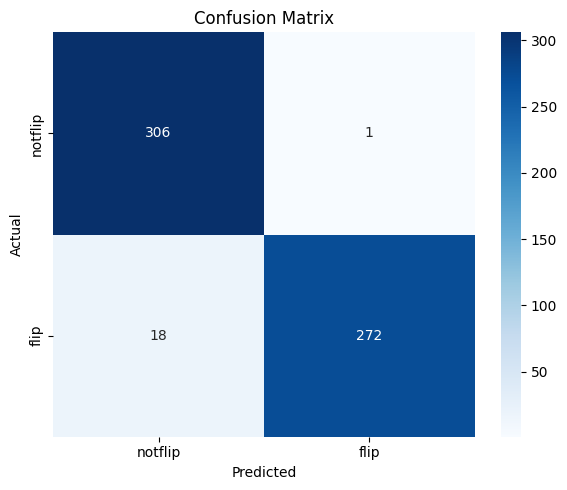

In [ ]:
# ============ 1. 分类报告 & 混淆矩阵 ============
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

print("=" * 50)
print("Classification Report")
print("=" * 50)
print(classification_report(all_labels, all_preds, target_names=classes))


cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout(); plt.show()

Using device: cpu
Train: 2392, Test: 597


Epoch 01 | Train Loss: 0.4572 Acc: 0.7621 | Test Loss: 0.6264 Acc: 0.6851 | ES: 0/2


Epoch 02 | Train Loss: 0.2178 Acc: 0.9110 | Test Loss: 1.5251 Acc: 0.5628 | ES: 0/2


Epoch 03 | Train Loss: 0.1211 Acc: 0.9532 | Test Loss: 0.3494 Acc: 0.8358 | ES: 1/2


Epoch 04 | Train Loss: 0.0772 Acc: 0.9699 | Test Loss: 0.0699 Acc: 0.9832 | ES: 0/2


...

Epoch 07 | Train Loss: 0.0358 Acc: 0.9858 | Test Loss: 0.0267 Acc: 0.9916 | ES: 0/2


Epoch 08 | Train Loss: 0.0304 Acc: 0.9891 | Test Loss: 0.1571 Acc: 0.9682 | ES: 0/2


Epoch 09 | Train Loss: 0.0263 Acc: 0.9908 | Test Loss: 0.0219 Acc: 0.9916 | ES: 1/2


Epoch 10 | Train Loss: 0.0303 Acc: 0.9904 | Test Loss: 0.0279 Acc: 0.9933 | ES: 0/2


Epoch 11 | Train Loss: 0.0261 Acc: 0.9904 | Test Loss: 0.1346 Acc: 0.9782 | ES: 1/2

>>> Early stopping at epoch 11. Best loss: 0.0219
Restored best model (epoch with test loss 0.0219)


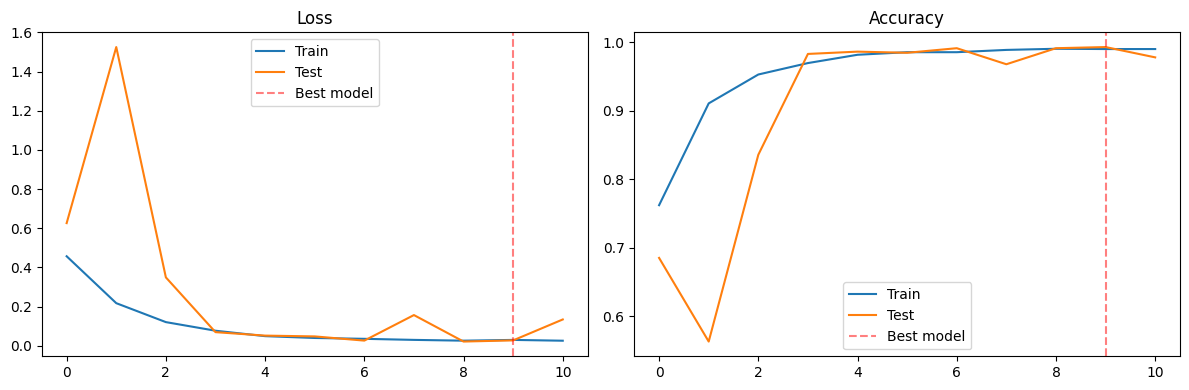

Model saved to flip_cnn_lion.pth


In [ ]:
!pip install lion-pytorch

import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import copy

base_path = "/content/images"
train_path = os.path.join(base_path, "training")
test_path = os.path.join(base_path, "testing")
classes = ["notflip", "flip"]

BATCH_SIZE = 64
IMG_SIZE = 96
NUM_WORKERS = 4
EPOCHS = 50
LR = 3e-4
WEIGHT_DECAY = 0.01
PATIENCE =2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ============ Dataset ============
class FlipDataset(Dataset):
    def __init__(self, root_path, transform=None):
        self.samples = []
        self.transform = transform
        for label, cls in enumerate(classes):
            cls_path = os.path.join(root_path, cls)
            for fname in os.listdir(cls_path):
                self.samples.append((os.path.join(cls_path, fname), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

# ============ Transforms============
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = FlipDataset(train_path, transform=train_transform)
test_dataset = FlipDataset(test_path, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

# ============ CNN ============
class FlipCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 96->48
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2: 48->24
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3: 24->12
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 4: 12->6
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(4),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)

model = FlipCNN().to(DEVICE)

# ============ Lion Optimizer ============
from lion_pytorch import Lion

criterion = nn.BCEWithLogitsLoss()
optimizer = Lion(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ============ Early Stopping ============
class EarlyStopping:
    def __init__(self, patience=2, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.best_model = None
        self.stopped_epoch = 0

    def step(self, val_loss, model, epoch):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
        self.stopped_epoch = epoch
        return self.counter >= self.patience

early_stopping = EarlyStopping(patience=PATIENCE)

# ============ ============
train_losses, test_losses = [], []
train_accs, test_accs = [], []

torch.backends.cudnn.benchmark = True

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False):
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.float().to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)  # 比zero_grad()更快
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # --- Eval ---
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.float().to(DEVICE, non_blocking=True)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).long()
            correct += (preds == labels.long()).sum().item()
            total += labels.size(0)

    test_loss = running_loss / total
    test_acc = correct / total
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f} Acc: {test_acc:.4f} | ES: {early_stopping.counter}/{PATIENCE}")

    # --- Early Stopping ---
    if early_stopping.step(test_loss, model, epoch + 1):
        print(f"\n>>> Early stopping at epoch {epoch+1}. Best loss: {early_stopping.best_loss:.4f}")
        break

model.load_state_dict(early_stopping.best_model)
print(f"Restored best model (epoch with test loss {early_stopping.best_loss:.4f})")

# ============ ============
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label="Train"); ax1.plot(test_losses, label="Test")
ax1.axvline(x=early_stopping.stopped_epoch - early_stopping.counter, color='r',
            linestyle='--', alpha=0.5, label='Best model')
ax1.set_title("Loss"); ax1.legend()
ax2.plot(train_accs, label="Train"); ax2.plot(test_accs, label="Test")
ax2.axvline(x=early_stopping.stopped_epoch - early_stopping.counter, color='r',
            linestyle='--', alpha=0.5, label='Best model')
ax2.set_title("Accuracy"); ax2.legend()
plt.tight_layout(); plt.show()

torch.save(model.state_dict(), "flip_cnn_lion.pth")
print("Model saved to flip_cnn_lion.pth")

In [ ]:
!pip install easyocr

  Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 48.1 MB/s eta 0:00:00
Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (180 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 33.4 MB/s eta 0:00:00


In [ ]:
import easyocr
reader = easyocr.Reader(['en'], gpu=True)

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [ ]:
result = reader.readtext('drive/My Drive/IMG_5769.JPEG')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
for detection in result:
  bbox, text, confidence = detection
  print(text)
  print(confidence)




RusTIc '5 JOURNEY To THE
0.2890368804295013
CENTURY
0.9982121676114997
attitudes
0.9999399471733929
imprinted
0.9999409507935317
on me_
0.6222002525227439
Tam ultra-careful with money and
0.729212365266984
His
0.9999878867191166
were
0.9979382753372192
wherever I have lived. Even when
0.9298196204887091
have
0.999984860420227
t0 raise a
0.7682473934367735
in rented abodes [ found
0.964250226319961
in vacant lots or
0.9294382693948638
community gar -
0.7540411556683633
TEN
0.825471918724253
dens My progeny might -
0.5960758307700691
this strange because I could
0.8771497492098563
anything
0.7501899539830924
wanted, but [
0.7035840686238019
A
0.7940396454133101
living life this way:
0.9884282000026124
My greatest sadness in life was the failure of my first
0.8741896229504471
considered marriage Vows sacred and never thought mine would be the
0.7331672276087141
ADVICE TO PROGENY
0.8413899480883101
first divorce in the family (there have been several since). I still believe
0.9531151534151

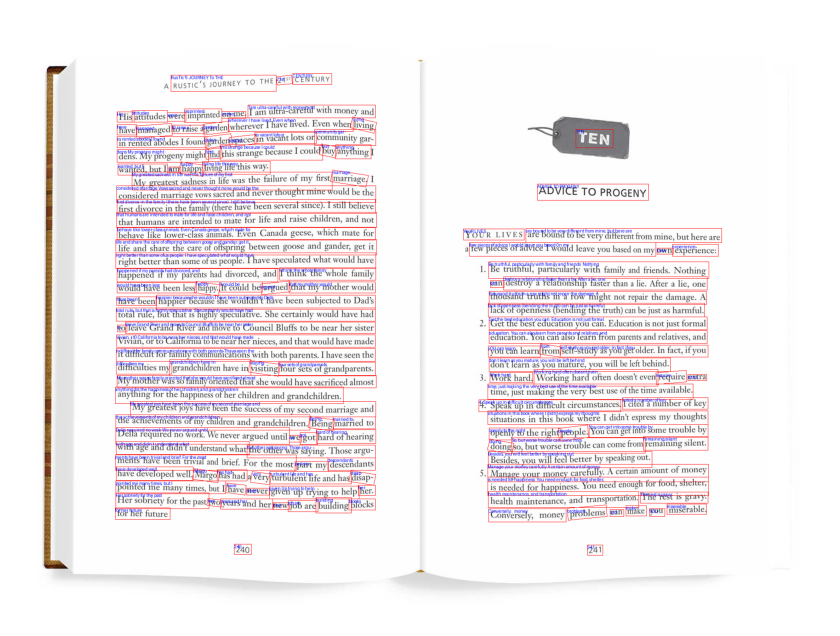

In [ ]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import numpy as np

img=Image.open('drive/My Drive/IMG_5769.JPEG')
draw=ImageDraw.Draw(img)

for bbox, text, confidence in result:
    pts = [tuple(p) for p in bbox]
    draw.polygon(pts, outline='red')
    draw.text(pts[0], text, fill='blue')

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.show()


In [ ]:
from transformers import LlavaNextProcessor, LlavaNextForConditionalGeneration
import torch
from PIL import Image

model_id = "llava-hf/llava-v1.6-mistral-7b-hf"
processor=LlavaNextProcessor.from_pretrained(model_id)
model= LlavaNextForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/accelerate/utils/modeling.py:1598: UserWarning: The following device_map keys do not match any submodules in the model: ['model.image_newline']
  warnings.warn(


In [ ]:
prompt = "[INST] <image>\nPlease extract and transcribe all the English text visible in this image. Output only the text, no explanation. [/INST]"

inputs = processor(
    text=prompt,
    images=image,
    return_tensors="pt"
).to("cuda")

with torch.no_grad():
    output = model.generate(
        **inputs,
        max_new_tokens=512,
        do_sample=False
    )

llava_text = processor.decode(output[0], skip_special_tokens=True)
llava_text = llava_text.split("[/INST]")[-1].strip()

print(llava_text)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


The text in the image is as follows:

---

A RUSTIC'S JOURNEY TO THE 21ST CENTURY

His attitudes were inspired on me. I am also careful with money and I am not a spendthrift. Even when living in rented abodes I found garden spaces in vacant lots or community gardens. I wanted to be happy living this way. I could buy anything I wanted, but I could not buy happiness. I considered marriage vows sacred and never thought mine would be severed. I still believe that marriage is the best way to have a family. I still believe that humans are intended to mate for life and raise children, and not have them raised by someone else.

I have been divorced twice. The first divorce was a disaster. I was a young man and I did not know how to handle it. I was devastated and I did not know how to cope with it. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. 

In [ ]:
!pip install -q transformers accelerate torchaudio
!pip install -q huggingface_hub

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import torch
from transformers import CsmForConditionalGeneration, AutoProcessor
model_id="sesame/csm-1b"
device = "cuda" if torch.cuda.is_available() else "cpu"
csm_processor=AutoProcessor.from_pretrained(model_id)
csm_model=CsmForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map=device
)

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/449 [00:00<?, ?B/s]

transformers.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/538 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/264 [00:00<?, ?B/s]

In [ ]:


lla_vatext="A RUSTIC'S JOURNEY TO THE 21ST CENTURY. His attitudes were inspired on me. I am also careful with money and I am not a spendthrift. Even when living in rented abodes I found garden spaces in vacant lots or community gardens. I wanted to be happy living this way. I could buy anything I wanted, but I could not buy happiness. I considered marriage vows sacred and never thought mine would be severed. I still believe that marriage is the best way to have a family. I still believe that humans are intended to mate for life and raise children, and not have them raised by someone else. I have been divorced twice. The first divorce was a disaster. I was a young man and I did not know how to handle it. I was devastated and I did not know how to cope with it. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time"

print(lla_vatext)

conversation = [
    {
        "role": "0",
        "content": [{"type": "text", "text": lla_vatext}]
    }
]

inputs = csm_processor.apply_chat_template(
    conversation,
    tokenize=True,
    return_dict=True,
).to(device)
with torch.no_grad():
    audio_output = csm_model.generate(**inputs, output_audio=True)


A RUSTIC'S JOURNEY TO THE 21ST CENTURY. His attitudes were inspired on me. I am also careful with money and I am not a spendthrift. Even when living in rented abodes I found garden spaces in vacant lots or community gardens. I wanted to be happy living this way. I could buy anything I wanted, but I could not buy happiness. I considered marriage vows sacred and never thought mine would be severed. I still believe that marriage is the best way to have a family. I still believe that humans are intended to mate for life and raise children, and not have them raised by someone else. I have been divorced twice. The first divorce was a disaster. I was a young man and I did not know how to handle it. I was devastated and I did not know how to cope with it. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not happy for a long time. I was not h

In [ ]:
output_path = "llava_ocr_speech.wav"
csm_processor.save_audio(audio_output, output_path)

In [ ]:
from IPython.display import Audio, display

display(Audio(output_path, autoplay=True))

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


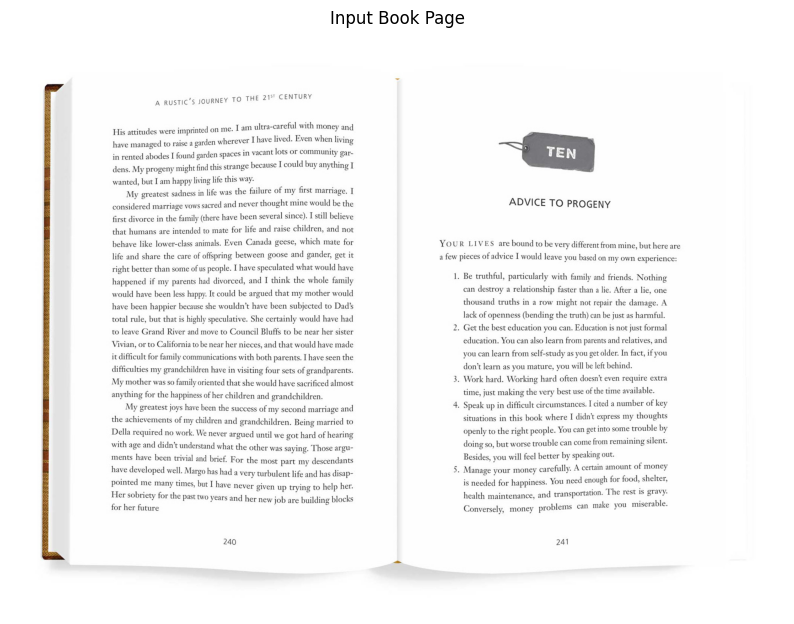

In [ ]:

from google.colab import drive
drive.mount('/content/drive/')

import shutil
import os

src = "/content/drive/MyDrive/IMG_5769.JPEG"
os.makedirs("/content/book_pipeline/data/raw", exist_ok=True)
shutil.copy(src, "/content/book_pipeline/data/raw/page.jpg")

from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/book_pipeline/data/raw/page.jpg")
plt.figure(figsize=(10, 12))
plt.imshow(img)
plt.axis('off')
plt.title("Input Book Page")
plt.show()

In [ ]:
import easyocr
import os
import json

INPUT_PATH = "/content/book_pipeline/data/raw/page.jpg"
OUTPUT_JSON = "/content/book_pipeline/data/processed/ocr_result.json"

os.makedirs(os.path.dirname(OUTPUT_JSON), exist_ok=True)

reader = easyocr.Reader(['en'])
results = reader.readtext(INPUT_PATH, detail=1)

formatted = []

for bbox, text, conf in results:
    formatted.append({
        "bbox": [[int(x), int(y)] for x, y in bbox],
        "text": str(text),
        "confidence": float(conf)
    })

with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(formatted, f, ensure_ascii=False, indent=2)

print("OCR complete.")

OCR complete.


In [ ]:
import json
import os

def test_ocr_output_exists():
    assert os.path.exists("/content/book_pipeline/data/processed/ocr_result.json")

def test_ocr_output_not_empty():
    with open("/content/book_pipeline/data/processed/ocr_result.json", "r", encoding="utf-8") as f:
        data = json.load(f)
    assert len(data) > 0

In [ ]:

!pip install dvc dvc-gdrive easyocr -q

In [ ]:
# Git + DVC
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content')

!git init book_pipeline
os.chdir('/content/book_pipeline')
!dvc init -f

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reinitialized existing Git repository in /content/book_pipeline/.git/
Initialized DVC repository.

You can now commit the changes to git.

+---------------------------------------------------------------------+
|                                                                     |
|        DVC has enabled anonymous aggregate usage analytics.         |
|     Read the analytics documentation (and how to opt-out) here:     |
|             <https://dvc.org/doc/user-guide/analytics>              |
|                                                                     |
+---------------------------------------------------------------------+

What's next?
------------
- Check out the documentation: <https://dvc.org/doc>
- Get help and share ideas: <https://dvc.org/chat>
- Star us on GitHub: <https://github.com/treeverse/dvc>


In [ ]:
# set address
GDRIVE_FOLDER_ID = "dt"

!dvc remote add -d myremote gdrive://{GDRIVE_FOLDER_ID}
!dvc remote modify myremote gdrive_acknowledge_abuse true
!git add .dvc/config
!git commit -m "configure gdrive remote"

Setting 'myremote' as a default remote.
[master 22f9b60] configure gdrive remote
 1 file changed, 5 insertions(+)


In [ ]:
# Cell 4: copy the photo into DVC
import shutil, os

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

shutil.copy("/content/drive/MyDrive/IMG_5769.JPEG", "data/raw/page.jpg")

# use DVC to track data
!dvc add data/raw/page.jpg
!git add data/raw/page.jpg.dvc data/raw/.gitignore
!git commit -m "add raw page image"

⠋ Checking graph
Adding...:   0% 0/1 [00:00<?, ?file/s{'info': ''}]
!
          |0.00 [00:00,     ?file/s]
                                    
!
  0% |          |0/? [00:00<?,    ?files/s]
                                           
Adding data/raw/page.jpg to cache:   0% 0/1 [00:00<?, ?file/s]
Adding data/raw/page.jpg to cache:   0% 0/1 [00:00<?, ?file/s{'info': ''}]
                                                                          
  0% 0/1 [00:00<?, ?files/s]
  0% 0/1 [00:00<?, ?files/s{'info': ''}]
Adding...: 100% 1/1 [00:00<00:00, 32.26file/s{'info': ''}]

To track the changes with git, run:

	git add data/raw/page.jpg.dvc

To enable auto staging, run:

	dvc config core.autostage true
On branch master
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   params.yaml
	modified:   src/__init__.py
	modified:   tests/__pycache__/test_preprocess.cpython-31

In [ ]:
# Cell 5: OCR
%%writefile src/run_ocr.py
import easyocr, json, os

INPUT_PATH  = "data/raw/page.jpg"
OUTPUT_JSON = "data/processed/ocr_result.json"

os.makedirs(os.path.dirname(OUTPUT_JSON), exist_ok=True)

reader  = easyocr.Reader(['en'])
results = reader.readtext(INPUT_PATH, detail=1)

formatted = [
    {"bbox": [[int(x), int(y)] for x, y in bbox],
     "text": str(text),
     "confidence": float(conf)}
    for bbox, text, conf in results
]

with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(formatted, f, ensure_ascii=False, indent=2)

print(f"OCR complete. {len(formatted)} blocks found.")

Writing src/run_ocr.py


In [ ]:
# test script
%%writefile src/test_ocr.py
import json, os, sys

def test_ocr_output_exists():
    assert os.path.exists("data/processed/ocr_result.json"), "输出文件不存在"

def test_ocr_output_not_empty():
    with open("data/processed/ocr_result.json", "r", encoding="utf-8") as f:
        data = json.load(f)
    assert len(data) > 0, "OCR 结果为空"

if __name__ == "__main__":
    test_ocr_output_exists()
    test_ocr_output_not_empty()
    print("All tests passed ✓")

Writing src/test_ocr.py


In [ ]:
# create dvc.yaml
%%writefile dvc.yaml
stages:
  ocr:
    cmd: python src/run_ocr.py
    deps:
      - src/run_ocr.py
      - data/raw/page.jpg
    outs:
      - data/processed/ocr_result.json

  test:
    cmd: python src/test_ocr.py
    deps:
      - src/test_ocr.py
      - data/processed/ocr_result.json

Overwriting dvc.yaml


In [ ]:
# add pipeline definition
!git add dvc.yaml src/
!git commit -m "add dvc pipeline"

[master 657d7cb] add dvc pipeline
 11 files changed, 319 insertions(+), 136 deletions(-)
 create mode 100644 dvc.yaml
 rewrite src/__init__.py (99%)
 create mode 100644 src/__pycache__/__init__.cpython-312.pyc
 create mode 100644 src/__pycache__/ocr.cpython-312.pyc
 create mode 100644 src/__pycache__/postprocess.cpython-312.pyc
 create mode 100644 src/__pycache__/preprocess.cpython-312.pyc
 create mode 100644 src/ocr.py
 create mode 100644 src/postprocess.py
 copy src/{__init__.py => preprocess.py} (67%)
 create mode 100644 src/run_ocr.py
 create mode 100644 src/test_ocr.py


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
os.chdir('/content/book_pipeline')

!mkdir -p /content/drive/MyDrive/dvc_storage

!dvc remote remove myremote 2>/dev/null || true
!dvc remote add -d myremote /content/drive/MyDrive/dvc_storage
!git add .dvc/config
!git commit -m "switch to local drive remote"

!dvc repro
!dvc push

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setting 'myremote' as a default remote.
[master 00a7d05] switch to local drive remote
 1 file changed, 1 insertion(+), 2 deletions(-)
'data/raw/page.jpg.dvc' didn't change, skipping
Stage 'ocr' didn't change, skipping
Stage 'test' didn't change, skipping
Data and pipelines are up to date.
Pushing
!
  0% |          |0/? [00:00<?,    ?files/s]
                                           
!
  0% |          |0/? [00:00<?,    ?files/s]
                                           
Pushing to local:   0% 0/2 [00:00<?, ?file/s]
Pushing to local:   0% 0/2 [00:00<?, ?file/s{'info': ''}]
Pushing to local:  50% 1/2 [00:00<00:00,  9.76file/s{'info': ''}]
Pushing
2 files pushed
